In this exercise, we will predict the number of applications received using the other variables in the College data set.

In [18]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from ISLP import load_data
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

In [7]:
College = load_data("College")
College.head()
College['Private'] = College['Private'].map({'Yes': 1, 'No': 0})

**(a)** Split the data set into a training set and a test set.

In [8]:
# Define X and y
X = College.drop(columns=["Apps"])
y = College["Apps"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

X_train.shape, X_test.shape

((543, 17), (234, 17))

**(b)** Fit a linear model using least squares and report test error.

In [9]:
lm = LinearRegression()
lm.fit(X_train, y_train)

pred_lm = lm.predict(X_test)
test_mse_lm = mean_squared_error(y_test, pred_lm)
test_mse_lm

1659682.1719134115

**(c)** Fit a ridge regression model with λ chosen by cross-validation.

In [10]:
# Define lambda grid
alphas = np.logspace(-3, 5, 200)

ridge = RidgeCV(alphas=alphas, scoring="neg_mean_squared_error")
ridge.fit(X_train, y_train)

pred_ridge = ridge.predict(X_test)
test_mse_ridge = mean_squared_error(y_test, pred_ridge)

ridge.alpha_, test_mse_ridge

(1.8041864093920719, 1655733.867558397)

**(d)** Fit a lasso model using cross-validation. Report test error and number of non-zero coefficients.

In [12]:
lasso = LassoCV(cv=10, random_state=0)
lasso.fit(X_train, y_train)

pred_lasso = lasso.predict(X_test)
test_mse_lasso = mean_squared_error(y_test, pred_lasso)

num_nonzero = np.sum(lasso.coef_ != 0)

lasso.alpha_, test_mse_lasso, num_nonzero

(56401.12601106401, 1914912.3699589907, 5)

**(e)** Fit a PCR model using cross-validation to choose M. Report selected M and test error.

In [13]:
m_values = range(1, X_train.shape[1] + 1)
cv_mse = []

for m in m_values:
    pcr_pipeline = Pipeline([
        ("scale", StandardScaler()),
        ("pca", PCA(n_components=m)),
        ("lm", LinearRegression())
    ])
    
    mse = -np.mean(
        cross_val_score(pcr_pipeline, X_train, y_train, 
                        scoring="neg_mean_squared_error", cv=10)
    )
    cv_mse.append(mse)

best_m = m_values[np.argmin(cv_mse)]
best_m

17

In [14]:
pcr = Pipeline([
    ("scale", StandardScaler()),
    ("pca", PCA(n_components=best_m)),
    ("lm", LinearRegression())
])

pcr.fit(X_train, y_train)
pred_pcr = pcr.predict(X_test)
test_mse_pcr = mean_squared_error(y_test, pred_pcr)

test_mse_pcr


1659682.1719133712

,Model,Test MSE,Test RMSE
0,Ridge,1.655734e+06,1286.753227
1,PCR,1.659682e+06,1288.286526
2,Linear Regression (OLS),1.659682e+06,1288.286526
3,Lasso,1.914912e+06,1383.803588


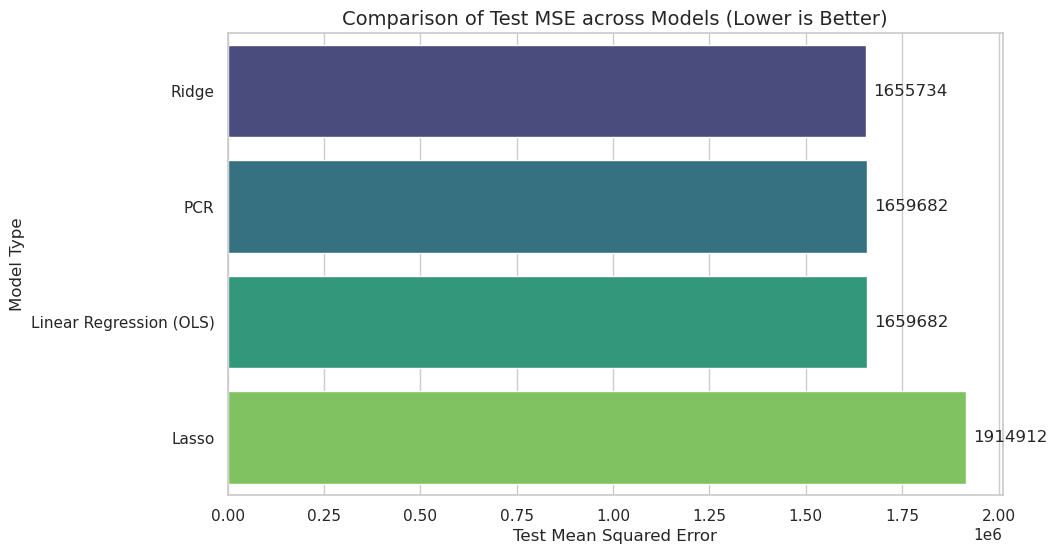

In [20]:
# 1. 建立結果表格
results_data = {
    'Model': ['Linear Regression (OLS)', 'Ridge', 'Lasso', 'PCR'],
    'Test MSE': [test_mse_lm, test_mse_ridge, test_mse_lasso, test_mse_pcr]
}

df_results = pd.DataFrame(results_data)

# 2. 為了更直觀，我們可以加一欄 RMSE (Root Mean Squared Error)
# RMSE 的單位與目標變數 'Apps' 相同，比較容易解釋誤差大小
df_results['Test RMSE'] = np.sqrt(df_results['Test MSE'])

# 依照 MSE 由小到大排序
df_results = df_results.sort_values(by='Test MSE', ascending=True).reset_index(drop=True)

# 顯示表格
display(df_results)

# 3. 繪製圖表 (Bar Chart)
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 繪製水平長條圖
ax = sns.barplot(x='Test MSE', y='Model', data=df_results, palette='viridis')

# 在長條圖上標註數值
for i in ax.containers:
    ax.bar_label(i, fmt='%.0f', padding=5)

plt.title('Comparison of Test MSE across Models (Lower is Better)', fontsize=14)
plt.xlabel('Test Mean Squared Error')
plt.ylabel('Model Type')

plt.show()